In [1]:
import numpy as np
import sys, os, re, math
import torch
from torch_geometric.loader import DataLoader
from model import GCN
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.lines import Line2D
import matplotlib.cm as cm

In [2]:
ds_dir = "../datasets"
gnns_dir = "../gnns"
version = "v4"
proteomeid_dict = {"HUMAN" : "UP000005640_9606",
                   "MOUSE" : "UP000000589_10090",
                   "RAT" : "UP000002494_10116",
                   "YEAST" : "UP000002311_559292"
                  }
annotation = "binding"

bs = 128 #batch size

In [3]:
rand_dict = {
    "5050": ["Random (50%)", #label for plot
             "#A0522D"], #color for plot
    "fraction": ["Random (1.6% " + '\u2013' + " 1.9%)",
                 "#D2B48C"]
}

frac_dict = {"HUMAN" : 0.017,
             "MOUSE" : 0.016,
             "RAT" : 0.017, 
             "YEAST" : 0.019
            }

In [4]:
#single cutoff data
single_cutoff_data_dict = {
    "cutoff4" : {
        'label' : r"4 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff4_1282",
        'hidden_neurons' : [112],
        'dropout_rates' : [0.276],
        'graph_type' : "cutoff4_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(7)},
    "cutoff6" : {
        'label' : r"6 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff6_1282",
        'hidden_neurons' : [118],
        'dropout_rates' : [0.308],
        'graph_type' : "cutoff6_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(6)},
    "cutoff8" : {
        'label' : r"8 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff8_1282",
        'hidden_neurons' : [297],
        'dropout_rates' : [0.439],
        'graph_type' : "cutoff8_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(5)},
    "cutoff10" : {
        'label' : r"10 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff10_1282",
        'hidden_neurons' : [85],
        'dropout_rates' : [0.648],
        'graph_type' : "cutoff10_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.Accent(4)},
    "cutoff12": {
        'label' : r"12 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff12_1282",
        'hidden_neurons' : [322],
        'dropout_rates' : [0.295],
        'graph_type' : "cutoff12_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(0)},
    "cutoff16": {
        'label' : r"16 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff16_1282",
        'hidden_neurons' : [59],
        'dropout_rates' : [0.263],
        'graph_type' : "cutoff16_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(1)},
    "cutoff20": {
        'label' : r"20 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff20_1282",
        'hidden_neurons' : [44],
        'dropout_rates' : [0.693],
        'graph_type' : "cutoff20_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(2)},
    "cutoff24": {
        'label' : r"24 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff24_1282",
        'hidden_neurons' : [9],
        'dropout_rates' : [0.507],
        'graph_type' : "cutoff24_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(3)}
}

#define two cutoffs data
hybrid_cutoff_data_dict = {
    "24|8 model, actual 24|8 graphs": {
        'label' : r"Actual 24 $\mathrm{\AA}$ | 8 $\mathrm{\AA}$-cutoff graphs",
        'model_path' : gnns_dir + "/model_cutoff_anno24_else8_1282",
        'hidden_neurons' : [98],
        'dropout_rates' : [0.357],
        'graph_type' : "cutoff_anno24_else8_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : "#d94801"},
    "24|8 model, predicted 24|8 graphs" : {
        'label': "Predicted 24 $\mathrm{\AA}$ | 8 $\mathrm{\AA}$-cutoff graphs",
        'model_path' : gnns_dir + "/model_cutoff_anno24_else8_1282",
        'hidden_neurons' : [98],
        'dropout_rates' : [0.357],
        'graph_type' : "cutoff_pred_anno24_else8_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : "#ff8c8c"},
    "24|8 model, 8 graphs": {
        'label' : "8 $\mathrm{\AA}$-cutoff graphs",
        'model_path' : gnns_dir + "/model_cutoff_anno24_else8_1282",
        'hidden_neurons' : [98],
        'dropout_rates' : [0.357],
        'graph_type' : "cutoff8_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : "#008b8b"},
    "24|8 model, 24 graphs": {
        'label' : "24 $\mathrm{\AA}$-cutoff graphs",
        'model_path' : gnns_dir + "/model_cutoff_anno24_else8_1282",
        'hidden_neurons' : [98],
        'dropout_rates' : [0.357],
        'graph_type' : "cutoff24_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : "#8fbc8f"},
}

cutoff_8_24_data_dict = {
    "anno8_else24": {
        'label' : "8 $\mathrm{\AA}$ | 24 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff_anno8_else24_1282",
        'hidden_neurons' : [12],
        'dropout_rates' : [0.260],
        'graph_type' : "cutoff_anno8_else24_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : "#DAA520"},
    "cutoff24": {
        'label' : "24 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff24_1282",
        'hidden_neurons' : [9],
        'dropout_rates' : [0.507],
        'graph_type' : "cutoff24_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(3)},
    "cutoff8" : {
        'label' : "8 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff8_1282",
        'hidden_neurons' : [297],
        'dropout_rates' : [0.439],
        'graph_type' : "cutoff8_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(5)},
}

#define node feature data
node_feat_data_dict = {
    "1282" : {
        'label' : "8 $\mathrm{\AA}$ GNN", #"Sequence-based & structure-based",
        'model_path' : gnns_dir + "/model_cutoff8_1282",
        'hidden_neurons' : [297],
        'dropout_rates' : [0.439],
        'graph_type' : "cutoff8_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(5)},
    "1280": {
        'label' : "GNN-sequence", 
        'model_path' : gnns_dir + "/model_cutoff8_1280_nohpo",
        'hidden_neurons' : [297],
        'dropout_rates' : [0.439],
        'graph_type' : "cutoff8_esm2embeddings",
        'linestyle' : '--',
        'color' : "#ff00ff"},
    "2": {
        'label': "GNN-structure", 
        'model_path' : gnns_dir + "/model_cutoff8_2_nohpo",
        'hidden_neurons' : [297],
        'dropout_rates' : [0.439],
        'graph_type' : "cutoff8_phipsi",
        'linestyle' : '--',
        'color': "#00bfff"}
}


In [5]:
#compute the precision-recall curves of each random strategy
#save the corresponding precision, recall, average precision into a dictionary
def prc_auc_rand (data_dict):
    rand5050_prc_auc_dict = {} #key = data_key; value = dictionary where key = organism and value is [precision, recall, average precision]
    randfrac_prc_auc_dict = {} #key = data_key; value = dictionary where key = organism and value is [precision, recall, average precision]
    for data_key in data_dict.keys():
        rand5050_prc_auc_dict[data_key] = {} #initialization
        randfrac_prc_auc_dict[data_key] = {}
        
    for organism, proteomeid in proteomeid_dict.items():
        
        for data_key in data_dict.keys():
            
            torch.manual_seed(12345)
            
            #load the dataset
            graph_type = data_dict[data_key]['graph_type']
            dataset_graphs = ds_dir + "/" + proteomeid + "_" + organism + "_" + version + "_" + annotation + "_" + graph_type + ".pt"
            dataset = torch.load(dataset_graphs, weights_only=False)
            out_labels = dataset[0].y.size()[1]
            
            #create batches
            data_loader = DataLoader(dataset, batch_size=bs, shuffle=False) #shuffle=True when training; turn it off here for testing
            
            for strategy in rand_dict.keys():
                print (organism, data_key, strategy)
                if strategy == 'fraction':
                    for d in range(len(dataset)):
                        data = dataset[d]
                        num_nodes = data.num_nodes
                        y_rand = np.zeros((num_nodes, out_labels))
                        num_nodes_rand = round(num_nodes * frac_dict[organism]) #select x% of the nodes of a graph
                        rand_indices = torch.randperm(num_nodes)[:num_nodes_rand]
                        y_rand[rand_indices] = 1
                        pred_rand = torch.tensor(y_rand, dtype=torch.float64)
                        data.y_rand = pred_rand
                        
                #random guess
                y_score = torch.empty(0)
                y_true = torch.empty(0)
                for i, data in enumerate(data_loader):
                    if strategy == '5050':
                        pred = torch.rand(data.y.size(), dtype=torch.float64)
                        
                    elif strategy == 'fraction':
                        pred = data.y_rand
    
                    target = data.y.type(torch.float) #convert target type from int to float
                    y_score = torch.cat((y_score, pred), dim = 0)
                    y_true = torch.cat((y_true, target), dim = 0)
                
                precision, recall, thresholds = precision_recall_curve(y_true, y_score)
                ap = average_precision_score(y_true, y_score) #average_precision
    
                if strategy == '5050':
                    rand5050_prc_auc_dict[data_key][organism] = [precision, recall, ap]
    
                elif strategy == 'fraction':
                    randfrac_prc_auc_dict[data_key][organism] = [precision, recall, ap]
                    
            del dataset
                
    #create label
    rand5050_prc_auc = []
    for data_key in data_dict.keys():
        for organism in proteomeid_dict.keys():
            rand_prc_auc = rand5050_prc_auc_dict[data_key][organism][2]
            rand5050_prc_auc.append(rand_prc_auc)
    rand5050_label = rand_dict["5050"][0] + ': ' + '%0.2f' % np.average(rand5050_prc_auc) + ' \u00b1 ' + '%0.2f' % np.std(rand5050_prc_auc)
    
    randfrac_prc_auc = []
    for data_key in data_dict.keys():
        for organism in proteomeid_dict.keys():
            rand_prc_auc = randfrac_prc_auc_dict[data_key][organism][2]
            randfrac_prc_auc.append(rand_prc_auc)
    randfrac_label = rand_dict["fraction"][0] + ': ' + '%0.2f' % np.average(randfrac_prc_auc) + ' \u00b1 ' + '%0.2f' % np.std(randfrac_prc_auc)

    return (rand5050_prc_auc_dict, randfrac_prc_auc_dict, rand5050_label, randfrac_label)


In [6]:
#compute the precision-recall curves of each model/graph combination
#save the corresponding precision, recall, average precision into a dictionary
def prc_auc_model (data_dict):
    data_prc_auc_dict = {} #key = data_key; value = dictionary where key = organism and value is a list of 10 [precision, recall, average precision]
    for data_key in data_dict.keys():
        data_prc_auc_dict[data_key] = {} #initialization
    
    for organism, proteomeid in proteomeid_dict.items():
        
        for data_key in data_dict.keys():
            
            print (organism, data_key)
            data_prc_auc_dict[data_key][organism] = []

            torch.manual_seed(12345)
            
            hidden_neurons = data_dict[data_key]['hidden_neurons']
            dropout_rates = data_dict[data_key]['dropout_rates']
            graph_type = data_dict[data_key]['graph_type']
            
            #load the dataset
            dataset_graphs = ds_dir + "/" + proteomeid + "_" + organism + "_" + version + "_" + annotation + "_" + graph_type + ".pt"
            dataset = torch.load(dataset_graphs, weights_only=False)
            inp_node_features = dataset[0].x.size()[1]
            out_labels = dataset[0].y.size()[1]
    
            #create batches
            data_loader = DataLoader(dataset, batch_size=bs, shuffle=False) #shuffle=True when training; turn it off here for testing
    
            for n in range(490, 500): #last ten epoch models
                model_path = data_dict[data_key]['model_path'] + '/model_' + str(n) 
                #load model
                neurons = [inp_node_features] + hidden_neurons + [out_labels] #neurons in each layer
                device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
                model = GCN(neurons).to(device)
                model.load_state_dict(torch.load(model_path))
        
                #evaluation
                y_score = torch.empty(0)
                y_true = torch.empty(0)
                for data in data_loader:
                    model.eval()
                    with torch.no_grad():
                        pred = model(data, dropout_rates)
                        y_score = torch.cat((y_score, pred), dim = 0)
                    target = data.y.type(torch.float)
                    y_true = torch.cat((y_true, target), dim = 0)
                
                #compute prc curve and prc area
                precision, recall, thresholds = precision_recall_curve(y_true, y_score)
                ap = average_precision_score(y_true, y_score)
                
                data_prc_auc_dict[data_key][organism].append([precision, recall, ap])
            
            del dataset

    #create label
    label_dict = {} #key = data_key; value = label (last epoch, i.e., epoch #499)
    for data_key in data_dict.keys():
        prc_auc1 = data_prc_auc_dict[data_key]["HUMAN"][9][2] #human
        prc_auc2 = data_prc_auc_dict[data_key]["MOUSE"][9][2] #mouse
        prc_auc3 = data_prc_auc_dict[data_key]["RAT"][9][2] #rat
        prc_auc4 = data_prc_auc_dict[data_key]["YEAST"][9][2] #yeast
        label_dict[data_key] = data_dict[data_key]['label'] + ': ' + '%0.2f' % prc_auc1 + ' ' + '%0.2f' % prc_auc2 + ' ' + '%0.2f' % prc_auc3 + ' ' + '%0.2f' % prc_auc4

    return (data_prc_auc_dict, label_dict)

In [7]:
rand5050_single_cutoff_prc_auc_dict, randfrac_single_cutoff_prc_auc_dict, rand5050_single_cutoff_label, randfrac_single_cutoff_label = prc_auc_rand(single_cutoff_data_dict)
single_cutoff_prc_auc_dict, single_cutoff_label_dict = prc_auc_model(single_cutoff_data_dict)

HUMAN cutoff4 5050
HUMAN cutoff4 fraction
HUMAN cutoff6 5050
HUMAN cutoff6 fraction
HUMAN cutoff8 5050
HUMAN cutoff8 fraction
HUMAN cutoff10 5050
HUMAN cutoff10 fraction
HUMAN cutoff12 5050
HUMAN cutoff12 fraction
HUMAN cutoff16 5050
HUMAN cutoff16 fraction
HUMAN cutoff20 5050
HUMAN cutoff20 fraction
HUMAN cutoff24 5050
HUMAN cutoff24 fraction
MOUSE cutoff4 5050
MOUSE cutoff4 fraction
MOUSE cutoff6 5050
MOUSE cutoff6 fraction
MOUSE cutoff8 5050
MOUSE cutoff8 fraction
MOUSE cutoff10 5050
MOUSE cutoff10 fraction
MOUSE cutoff12 5050
MOUSE cutoff12 fraction
MOUSE cutoff16 5050
MOUSE cutoff16 fraction
MOUSE cutoff20 5050
MOUSE cutoff20 fraction
MOUSE cutoff24 5050
MOUSE cutoff24 fraction
RAT cutoff4 5050
RAT cutoff4 fraction
RAT cutoff6 5050
RAT cutoff6 fraction
RAT cutoff8 5050
RAT cutoff8 fraction
RAT cutoff10 5050
RAT cutoff10 fraction
RAT cutoff12 5050
RAT cutoff12 fraction
RAT cutoff16 5050
RAT cutoff16 fraction
RAT cutoff20 5050
RAT cutoff20 fraction
RAT cutoff24 5050
RAT cutoff24 fra

In [8]:
hybrid_cutoff_prc_auc_dict, hybrid_cutoff_label_dict = prc_auc_model(hybrid_cutoff_data_dict)

HUMAN 24|8 model, actual 24|8 graphs
HUMAN 24|8 model, predicted 24|8 graphs
HUMAN 24|8 model, 8 graphs
HUMAN 24|8 model, 24 graphs
MOUSE 24|8 model, actual 24|8 graphs
MOUSE 24|8 model, predicted 24|8 graphs
MOUSE 24|8 model, 8 graphs
MOUSE 24|8 model, 24 graphs
RAT 24|8 model, actual 24|8 graphs
RAT 24|8 model, predicted 24|8 graphs
RAT 24|8 model, 8 graphs
RAT 24|8 model, 24 graphs
YEAST 24|8 model, actual 24|8 graphs
YEAST 24|8 model, predicted 24|8 graphs
YEAST 24|8 model, 8 graphs
YEAST 24|8 model, 24 graphs


In [9]:
cutoff_8_24_prc_auc_dict, cutoff_8_24_label_dict = prc_auc_model(cutoff_8_24_data_dict)

HUMAN anno8_else24
HUMAN cutoff24
HUMAN cutoff8
MOUSE anno8_else24
MOUSE cutoff24
MOUSE cutoff8
RAT anno8_else24
RAT cutoff24
RAT cutoff8
YEAST anno8_else24
YEAST cutoff24
YEAST cutoff8


In [10]:
node_feat_prc_auc_dict, node_feat_label_dict = prc_auc_model(node_feat_data_dict)

HUMAN 1282
HUMAN 1280
HUMAN 2
MOUSE 1282
MOUSE 1280
MOUSE 2
RAT 1282
RAT 1280
RAT 2
YEAST 1282
YEAST 1280
YEAST 2


In [11]:
#plot precision-recall curves
def plot_auprc_curves_w_random(data_dict,
                               data_prc_auc_dict,
                               rand5050_prc_auc_dict, 
                               randfrac_prc_auc_dict, 
                               label_dict, 
                               rand5050_label, 
                               randfrac_label):
    mpl.rcParams['font.sans-serif'] = "Arial"
    plt.rcParams.update({'font.size': 16})
    fig, axes = plt.subplots(nrows=1, ncols=len(proteomeid_dict.keys()), sharex=True, sharey=True, figsize=(18,4))
    plt.subplots_adjust(top=0.90, wspace=0.10)
    
    axes = axes.flatten()
    
    for x, organism in enumerate(proteomeid_dict.keys()): #col
        ax = axes[x]
        
        for data_key in data_dict.keys():
            label = label_dict[data_key]
            color = data_dict[data_key]['color']
            linestyle = data_dict[data_key]['linestyle']

            aucs = []
            precisions = []
            base_recall = np.linspace(0, 1, 100)
            for i in range(10):
                # Interpolate precision at fixed base recall
                precision = data_prc_auc_dict[data_key][organism][i][0]
                recall = data_prc_auc_dict[data_key][organism][i][1]
                aucprc = data_prc_auc_dict[data_key][organism][i][2]
                precision_interp = np.interp(base_recall, recall[::-1], precision[::-1])
                precisions.append(precision_interp)
                aucs.append(aucprc)
            
            mean_precisions = np.mean(precisions, axis=0)
            error_precisions = float(1.96) * np.std(precisions, axis=0) / np.sqrt(10) #95% confidence intervals
            
            # Create bounds
            precisions_upper = np.minimum(mean_precisions + error_precisions, 1)
            precisions_lower = np.maximum(mean_precisions - error_precisions, 0)
            
            # Plot the shaded standard deviation
            ax.fill_between(base_recall, precisions_lower, precisions_upper, color=color, alpha=0.5, linewidth=0)
            
            # Plot Mean PRC
            #mean_auc = auc(base_recall, mean_precisions)
            #print (organism, data_key, mean_auc, np.mean(aucs))
            #ax.plot(base_recall, mean_precisions, color=color, linewidth=3, linestyle=linestyle, label=label)
            ax.plot(data_prc_auc_dict[data_key][organism][9][1], data_prc_auc_dict[data_key][organism][9][0], color=color, linewidth=3, linestyle=linestyle, label=label)
            #ax.plot([0, 1], [0, 1], 'k--')
            
        for data_key in rand5050_prc_auc_dict.keys():
            label = rand5050_label
            color = rand_dict["5050"][1]
            precision = rand5050_prc_auc_dict[data_key][organism][0]
            recall = rand5050_prc_auc_dict[data_key][organism][1]
            prc_auc = rand5050_prc_auc_dict[data_key][organism][2]
            
            ax.plot(recall, precision, color=color, linewidth=3, linestyle="--", label=label)
            
        for data_key in randfrac_prc_auc_dict.keys():
            label = randfrac_label
            color = rand_dict["fraction"][1]
            precision = randfrac_prc_auc_dict[data_key][organism][0]
            recall = randfrac_prc_auc_dict[data_key][organism][1]
            prc_auc = randfrac_prc_auc_dict[data_key][organism][2]
            
            ax.plot(recall, precision, color=color, linewidth=3, linestyle=":", label=label)
        
        if x == len(proteomeid_dict.keys()) - 1:
            # Create a unique set of handles and labels
            h, l = ax.get_legend_handles_labels()
            unique_handles = []
            unique_labels = []
            for handle, label in zip(h, l):
                if label not in unique_labels:
                    unique_handles.append(handle)
                    unique_labels.append(label)
            leg = ax.legend(unique_handles, unique_labels, frameon=True, bbox_to_anchor = (1.02, 1.00), markerscale=1, labelspacing=0.2, handletextpad=0.5)
            
            leg.set_title("AUPRC:")
            leg._legend_box.align = "left"
            
        elif x == 0:
            ax.set_ylabel('Precision')
            
        if organism == 'HUMAN':
            title = organism.title() + " (Train)"
        else:
            title = organism.title() + " (Test)"
    
        ax.set_title(title, y=1.02)
        ax.set_xlim([0,1.0])
        ax.set_ylim([0,1.0])
        ticks = np.arange(0, 1.1, 0.2)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xlabel('Recall')
    
    plt.show()
    fig.clf()
    return

def plot_auprc_curves(data_dict,
                      data_prc_auc_dict,
                      label_dict):
    mpl.rcParams['font.sans-serif'] = "Arial"
    plt.rcParams.update({'font.size': 16})
    fig, axes = plt.subplots(nrows=1, ncols=len(proteomeid_dict.keys()), sharex=True, sharey=True, figsize=(18,4))
    plt.subplots_adjust(top=0.90, wspace=0.10)
    
    axes = axes.flatten()
    
    for x, organism in enumerate(proteomeid_dict.keys()): #col
        ax = axes[x]
        
        for data_key in data_dict.keys():
            label = label_dict[data_key]
            color = data_dict[data_key]['color']
            linestyle = data_dict[data_key]['linestyle']
    
            aucs = []
            precisions = []
            base_recall = np.linspace(0, 1, 100)
            for i in range(10):
                # Interpolate precision at fixed base recall
                precision = data_prc_auc_dict[data_key][organism][i][0]
                recall = data_prc_auc_dict[data_key][organism][i][1]
                aucprc = data_prc_auc_dict[data_key][organism][i][2]
                precision_interp = np.interp(base_recall, recall[::-1], precision[::-1])
                precisions.append(precision_interp)
                aucs.append(aucprc)
            
            mean_precisions = np.mean(precisions, axis=0)
            error_precisions = float(1.96) * np.std(precisions, axis=0) / np.sqrt(10) #95% confidence intervals
            
            # Create bounds
            precisions_upper = np.minimum(mean_precisions + error_precisions, 1)
            precisions_lower = np.maximum(mean_precisions - error_precisions, 0)
            
            # Plot the shaded standard deviation
            ax.fill_between(base_recall, precisions_lower, precisions_upper, color=color, alpha=0.5, linewidth=0)
            
            # Plot Mean PRC
            #mean_auc = auc(base_recall, mean_precisions)
            #print (organism, data_key, mean_auc, np.mean(aucs))
            #ax.plot(base_recall, mean_precisions, color=color, linewidth=3, linestyle=linestyle, label=label)
            ax.plot(data_prc_auc_dict[data_key][organism][9][1], data_prc_auc_dict[data_key][organism][9][0], color=color, linewidth=3, linestyle=linestyle, label=label)
            #ax.plot([0, 1], [0, 1], 'k--')
            
        if x == len(proteomeid_dict.keys()) - 1:
            # Create a unique set of handles and labels
            h, l = ax.get_legend_handles_labels()
            unique_handles = []
            unique_labels = []
            for handle, label in zip(h, l):
                if label not in unique_labels:
                    unique_handles.append(handle)
                    unique_labels.append(label)
            leg = ax.legend(unique_handles, unique_labels, frameon=True, bbox_to_anchor = (1.02, 1.00), markerscale=1, labelspacing=0.2, handletextpad=0.5)
            
            leg.set_title("AUPRC:")
            leg._legend_box.align = "left"
            
        elif x == 0:
            ax.set_ylabel('Precision')
            
        if organism == 'HUMAN':
            title = organism.title() + " (Train)"
        else:
            title = organism.title() + " (Test)"
    
        ax.set_title(title, y=1.02)
        ax.set_xlim([0,1.0])
        ax.set_ylim([0,1.0])
        ticks = np.arange(0, 1.1, 0.2)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xlabel('Recall')
    
    plt.show()
    fig.clf()
    return


In [12]:
#plot precision-recall curves
def plot_auprc_bars_w_random(data_dict,
                             data_prc_auc_dict,
                             rand5050_prc_auc_dict, 
                             randfrac_prc_auc_dict, 
                             label_dict, 
                             rand5050_label, 
                             randfrac_label):
    mpl.rcParams['font.sans-serif'] = "Arial"
    plt.rcParams.update({'font.size': 16})
    fig, axes = plt.subplots(nrows=1, ncols=len(proteomeid_dict.keys()), sharex=True, sharey=True, figsize=(16,4))
    plt.subplots_adjust(top=0.90, wspace=0.10)
    
    axes = axes.flatten()
    width = 0.85 

    for x, organism in enumerate(proteomeid_dict.keys()): #col
        ax = axes[x]
        for i, data_key in enumerate(data_dict.keys()):
            label = data_dict[data_key]['label']
            color = data_dict[data_key]['color']
            linestyle = data_dict[data_key]['linestyle']

            aucs = []
            for j in range(10):
                aucprc = data_prc_auc_dict[data_key][organism][j][2]
                aucs.append(aucprc)
            
            mean_auc = np.mean(aucs)
            error_auc = float(1.96) * np.std(aucs) / np.sqrt(10) #95% confidence intervals
    
            p = ax.bar(i, aucs[-1], yerr=error_auc, capsize=5, width=width, color=color, edgecolor=color) #, label=label)
            ax.bar_label(p, fmt='{:,.2f}', padding=3, fontsize = 11)
            
        for data_key in rand5050_prc_auc_dict.keys():
            label = rand_dict["5050"][0]
            color = rand_dict["5050"][1]
            prc_auc = rand5050_prc_auc_dict[data_key][organism][2]
            ax.axhline(prc_auc, color=color, linewidth=3, linestyle="--", label=label)
            
        for data_key in randfrac_prc_auc_dict.keys():
            label = rand_dict["fraction"][0]
            color = rand_dict["fraction"][1]
            prc_auc = randfrac_prc_auc_dict[data_key][organism][2]
            ax.axhline(prc_auc, color=color, linewidth=3, linestyle=":", label=label)
            
        if x == len(proteomeid_dict.keys()) - 1:
            # Create a unique set of handles and labels
            h, l = ax.get_legend_handles_labels()
            unique_handles = []
            unique_labels = []
            for handle, label in zip(h, l):
                if label not in unique_labels:
                    unique_handles.append(handle)
                    unique_labels.append(label)
            leg = ax.legend(unique_handles, unique_labels, frameon=True, bbox_to_anchor = (2.15, 1.0), markerscale=1, labelspacing=0.2, handletextpad=0.5)
            leg._legend_box.align = "left"
            
        elif x == 0:
            ax.set_ylabel('AUPRC')
            
        if organism == 'HUMAN':
            title = organism.title() + " (Train)"
        else:
            title = organism.title() + " (Test)"
    
        ax.set_title(title, y=1.02)
        #ax.set_xlim([0,1.0])
        ax.set_xticks([0,1,2,3,4,5,6,7])
        ax.set_xticklabels(["4", "6", "8", "10", "12", "16", "20", "24"])#, rotation=90)
        ax.set_ylim([0,1.0])
        ticks = np.arange(0, 1.1, 0.2)
        #ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xlabel('Cutoff distance ($\mathrm{\AA}$)')
    
    plt.show()
    fig.clf()
    return

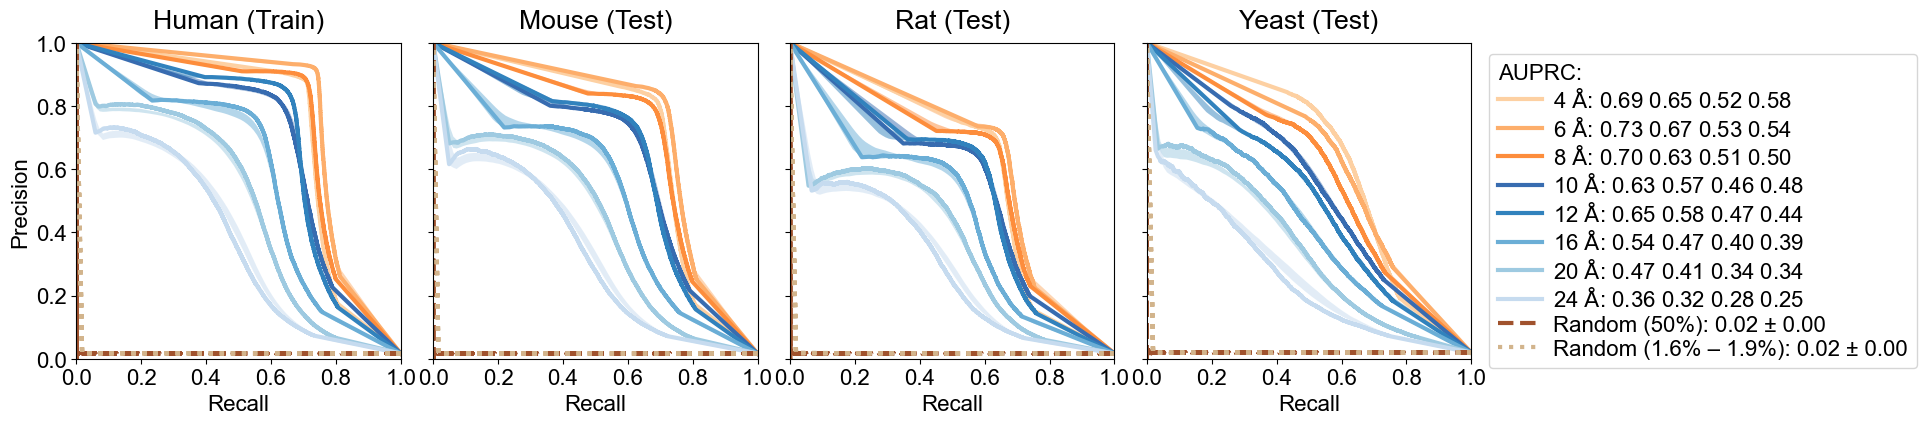

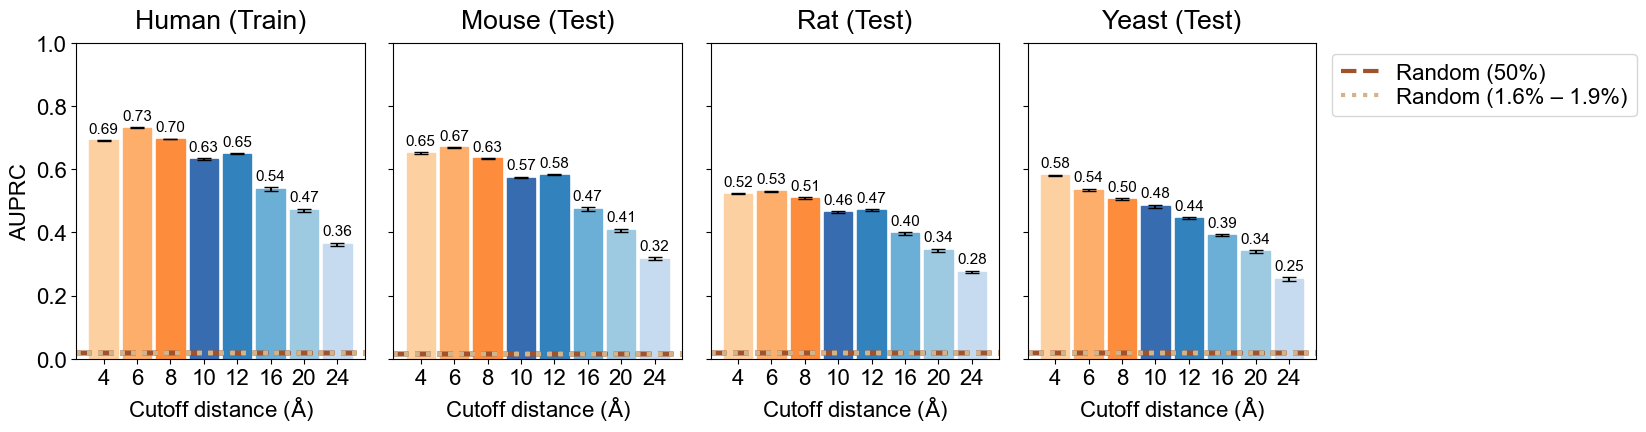

In [13]:
plot_auprc_curves_w_random(single_cutoff_data_dict,
                           single_cutoff_prc_auc_dict,
                           rand5050_single_cutoff_prc_auc_dict, 
                           randfrac_single_cutoff_prc_auc_dict, 
                           single_cutoff_label_dict, 
                           rand5050_single_cutoff_label, 
                           randfrac_single_cutoff_label)

plot_auprc_bars_w_random(single_cutoff_data_dict,
                         single_cutoff_prc_auc_dict,
                         rand5050_single_cutoff_prc_auc_dict, 
                         randfrac_single_cutoff_prc_auc_dict, 
                         single_cutoff_label_dict, 
                         rand5050_single_cutoff_label, 
                         randfrac_single_cutoff_label)

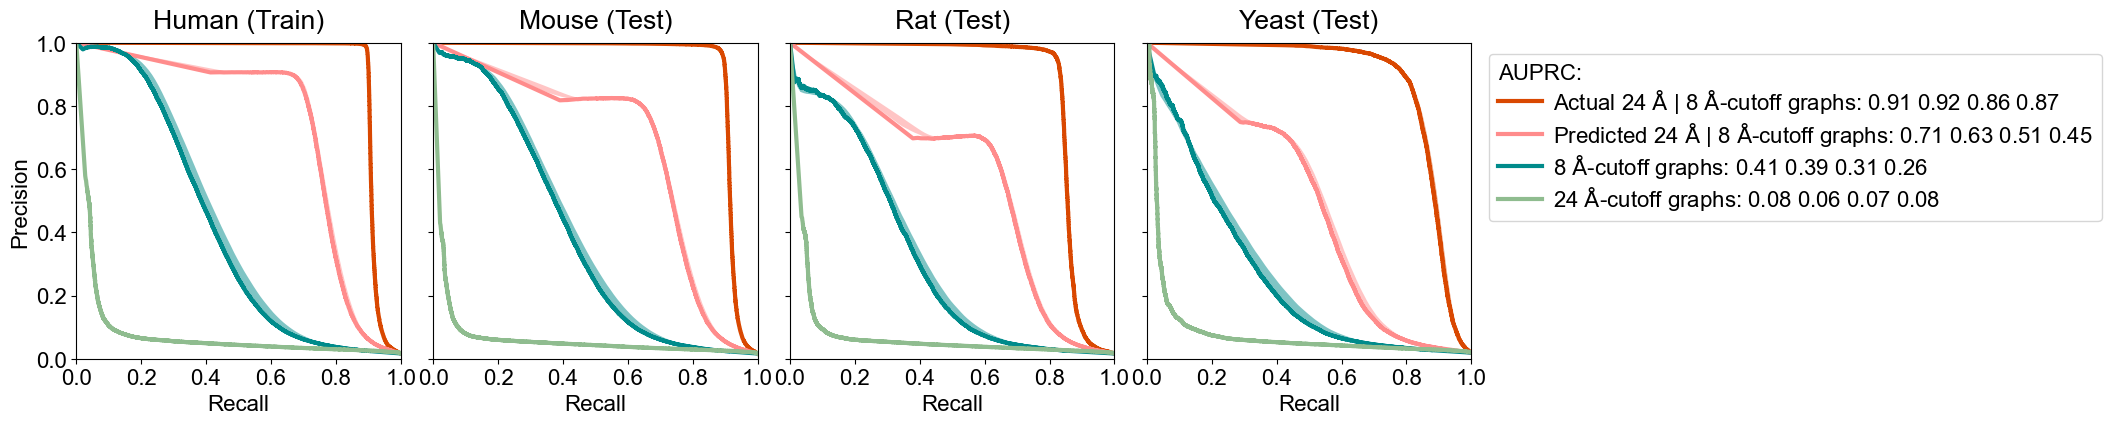

In [14]:
plot_auprc_curves(hybrid_cutoff_data_dict,
                  hybrid_cutoff_prc_auc_dict,
                  hybrid_cutoff_label_dict)

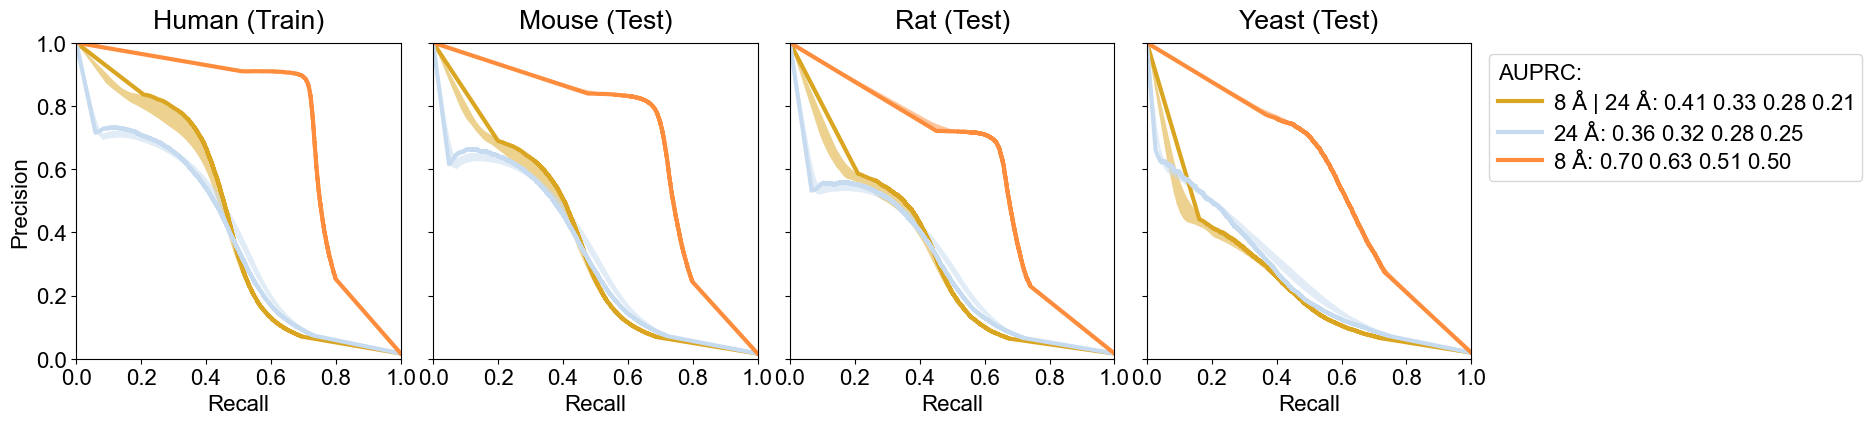

In [15]:
plot_auprc_curves(cutoff_8_24_data_dict,
                  cutoff_8_24_prc_auc_dict,
                  cutoff_8_24_label_dict)

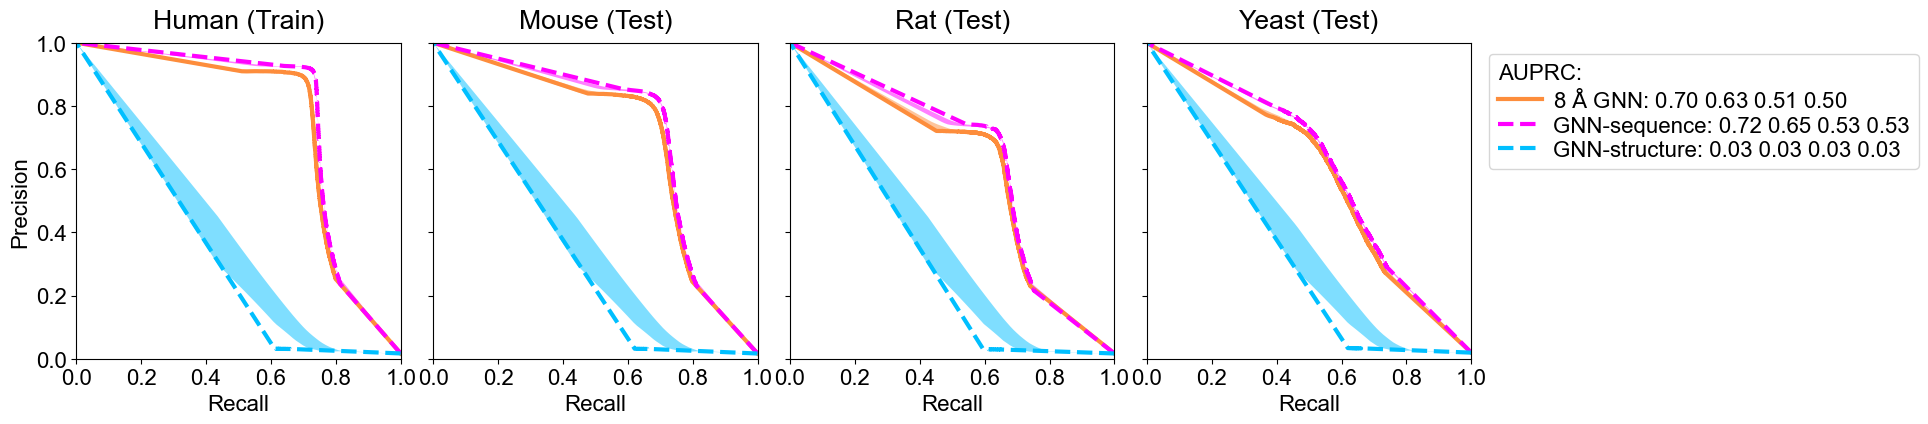

In [16]:
plot_auprc_curves(node_feat_data_dict,
                  node_feat_prc_auc_dict,
                  node_feat_label_dict)